# Оптимизация параметров застройки с помощью LLM  агентов
1. Устновить ollama с помощью brew (brew install ollama)
2. Запустить ollama сервер (ollama serve)
3. Убедитесь, что сервер расположен на порте 11434
4. Скачайте модель (ollama pull llama3)
5. После установки проверьте работоспособность (ollama run llama3)

In [1]:
from catboost import CatBoostRegressor
import pandas as pd
from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('/Users/andreyfeduhin/Downloads/Urbanomy/examples/land_value_modeling/catboost_model.cbm')  # модель на лог-цене

/Users/andreyfeduhin/Downloads/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

scenario_blocks = pd.read_pickle('/Users/andreyfeduhin/Urbanomy-data/data/leningrad_oblast/shlisselburg/scenario_blocks.pickle') #or baseline_blocks
context_blocks = pd.read_pickle('/Users/andreyfeduhin/Urbanomy-data/data/leningrad_oblast/shlisselburg/context_blocks.pickle')


In [3]:
from urbanomy.methods.land_value_modeling.land_data_preparation import LandDataPreparator

preparator = LandDataPreparator(
    scenario_blocks_source=scenario_blocks,
    context_blocks_source=context_blocks,
    predict_project_only=False, 
)

prepared_blocks = preparator.prepare()
prepared_blocks.head()

/Users/andreyfeduhin/Downloads/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
2026-01-11 01:38:02.108 | WARNING  | blocksnet.analysis.morphotypes.schemas:_before_validate:17 - Column l not found in columns. Calculating from fsi and gsi


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.332176,...,202399.732193,0.062008,0.030931,0.000000,2.004750,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.787308,...,201529.493481,0.202340,0.090030,0.000000,2.247466,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.643138,...,164663.859830,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.045942,...,161571.832511,0.449142,0.139053,0.404539,3.230006,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,16.489152,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

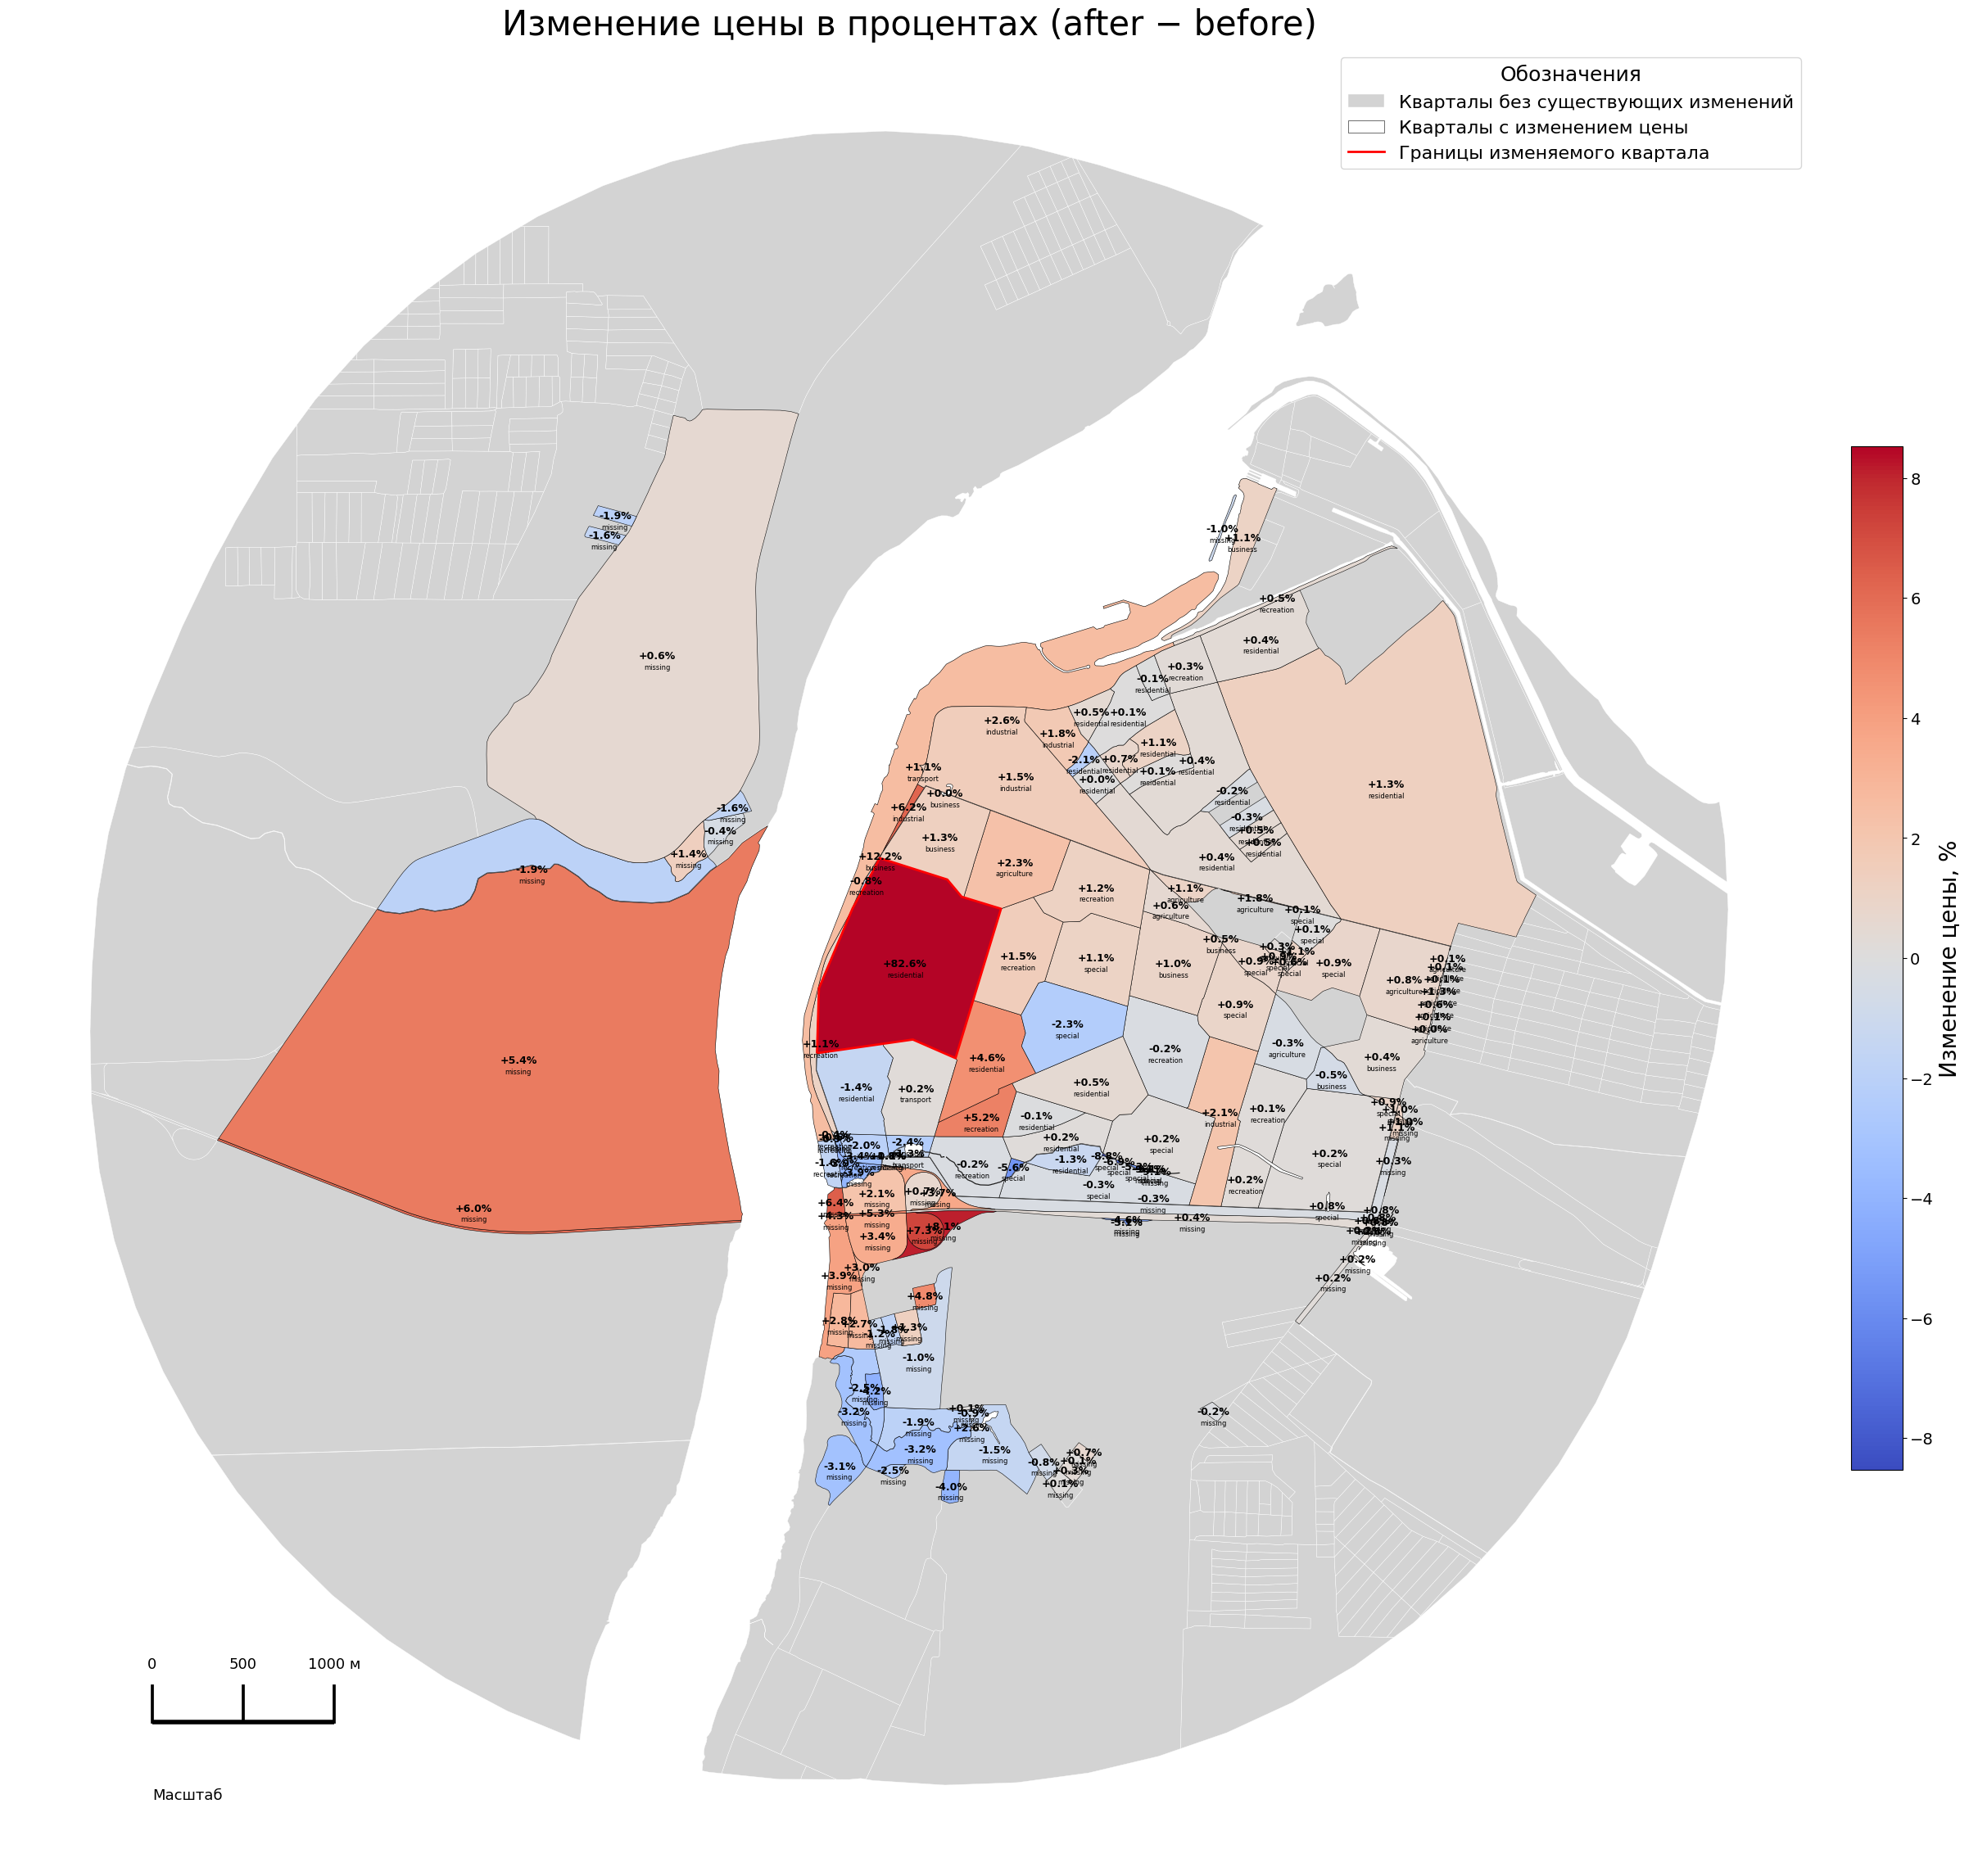


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
62 | residential | 223 337 143 ₽ → 407 776 656 ₽ | +184 439 513 ₽ | +82.6%

Кварталы в границах проекта:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
12 | special | 162 321 450 ₽ → 161 807 582 ₽ | -513 868 ₽ | -0.3%
48 | missing | 58 415 ₽ → 53 092 ₽ | -5 323 ₽ | -9.1%
49 | special | 57 246 ₽ → 52 029 ₽ | -5 217 ₽ | -9.1%
63 | special | 8 287 150 ₽ → 8 364 865 ₽ | +77 716 ₽ | +0.9%
38 | business | 154 660 164 ₽ → 155 270 412 ₽ | +610 248 ₽ | +0.4%
69 | special | 46 663 ₽ → 47 054 ₽ | +391 ₽ | +0.8%
13 | recreation | 51 613 679 ₽ → 51 731 224 ₽ | +117 545 ₽ | +0.2%
40 | special | 274 697 126 ₽ → 275 234 655 ₽ | +537 529 ₽ | +0.2%
14 | recreation | 82 367 707 ₽ → 82 486 216 ₽ | +118 509 ₽ | +0.1%
39 | business | 43 444 744 ₽ → 43 212 758 ₽ | -231 986 ₽ | -0.5%
16 | agriculture | 92 336 583 ₽ → 92 027 811 ₽ | -308 772 ₽ | -0.3%
19 | special | 55 988 961 ₽ → 56 467 0

In [5]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = prepared_blocks.copy()
changes = {
    'land_use': 'LandUse.RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    target_idx=target_idx,
    figsize=(25, 35),
)



In [6]:
from urbanomy.methods.land_value_modeling.scenario_modification import GeneticOptimizer
blocks_before["site_area"].iloc[62]

np.float64(754445.5932128676)

In [7]:
site_area = float(blocks_before["site_area"].iloc[62])
floors_neighborhood_avg = blocks_before['build_floor_area'].mean() 
optimizer = GeneticOptimizer(
    blocks_before=blocks_before,
    target_idx=target_idx,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    },
    constraints = {
    # Площадь пятна застройки
    "footprint_area": {
        "type": "float",
        "min": 0.0,
        "max": 0.8 * site_area,
    },
    # Площадь всех этажей
    "build_floor_area": {
        "type": "float",
        "min": site_area,
        "max": floors_neighborhood_avg*2,  
    },
    # Жилая площадь
    "living_area": {
        "type": "float",
        "min": 0.0,
        "max": floors_neighborhood_avg*2,  
    },
    # land_use 
    "residential": {"type": "float", "min": 0.0, "max": 1.0},
        "business":    {"type": "float", "min": 0.0, "max": 1.0},
        "recreation":  {"type": "float", "min": 0.0, "max": 1.0},
        "industrial":  {"type": "float", "min": 0.0, "max": 1.0},
        "transport":   {"type": "float", "min": 0.0, "max": 1.0},
        "special":     {"type": "float", "min": 0.0, "max": 1.0},
        "agriculture": {"type": "float", "min": 0.0, "max": 1.0}}, random_state=42)

In [8]:
best_score,best_genome = optimizer.optimize(generations=10, population_size=20)


Gen 0: best = 961269659.4792
Gen 1: best = 999969608.4687
Gen 2: best = 999969608.4687
Gen 3: best = 1074221504.9772
Gen 4: best = 1098482138.3698
Gen 5: best = 1124151806.8526
Gen 6: best = 1149303735.1448
Gen 7: best = 1175559368.7352
Gen 8: best = 1185772632.0107
Gen 9: best = 1187834512.1576


In [9]:
best_genome

{'footprint_area': 185602.14140859767,
 'build_floor_area': np.float64(713549.4071148915),
 'living_area': np.float64(42520.25700543733),
 'residential': 0.5253842561394965,
 'business': 0.0416102144911735,
 'recreation': 0.032945068143161504,
 'industrial': 0.026452723505573716,
 'transport': 0.2665428428746236,
 'special': 0.0,
 'agriculture': 0.10706489484597126,
 'non_living_area': np.float64(671029.1501094542),
 'population': np.float64(2126.0128502718662),
 'land_use': <LandUse.RESIDENTIAL: 'residential'>}

In [8]:
changable_params = ['footprint_area', 'build_floor_area', 'living_area', 'residential', 'business', 'recreation', 'industrial', 'transport', 'special', 'agriculture']

In [9]:
genome_for_llm = blocks_before.loc[62][changable_params].to_dict()
genome_for_llm

{'footprint_area': 46479.52555836447,
 'build_floor_area': 81159.15254382326,
 'living_area': 0.0,
 'residential': 0.0,
 'business': 0.0,
 'recreation': 0.9530858666714253,
 'industrial': 0.0,
 'transport': 0.0,
 'special': 0.0,
 'agriculture': 0.0}

In [10]:
from urbanomy.methods.land_value_modeling.llm_agents import OllamaLLM, CityAdministrationAgent, ResidentsAgent, InvestorsAgent, DeveloperAggregator, run_multiagent_loop

llm = OllamaLLM(model="llama3", temperature=0.7)

print(llm.generate("Скажи одним предложением, что такое город"))

Город - это густонаселенный и организованный комплекс сооружений, инфраструктуры и общественных учреждений, объединяющий людей в социальную среду и обеспечивающий их жизнь, труд и развлечения.


In [11]:
agents = [
    CityAdministrationAgent("city", llm),
    ResidentsAgent("residents", llm),
    InvestorsAgent("investors", llm),
]

In [12]:
aggregator = DeveloperAggregator(
    llm=llm,
    agents=agents
)

In [19]:
# 1. Стартовый геном 
genome_for_llm = blocks_before.loc[62][changable_params].to_dict()

# 2. Multi-agent переговоры
genome = run_multiagent_loop(
    initial_genome=genome_for_llm,
    aggregator=aggregator,
    n_steps=3
)


=== STEP 0 ===
Response from city: As the administration of this city, I would like to focus on optimizing the urban development in order to achieve a more sustainable and balanced environment.

Firstly, regarding transportation, I would aim to reduce the transport load by implementing pedestrian-friendly and bike-friendly infrastructure. This could include expanding sidewalks, bike lanes, and pedestrian crossings, as well as introducing public transportation options that are efficient and convenient for citizens.

Secondly, to ensure a stable density, I would work on promoting mixed-use development, where residential areas are located near commercial centers, schools, parks, and other community facilities. This would reduce the need for lengthy commutes and encourage people to live in close proximity to their workplaces and services.

Lastly, to avoid an imbalance towards industrial activities, I would focus on diversifying the local economy by supporting small businesses, entreprene

In [20]:
genome_for_llm

{'footprint_area': 46479.52555836447,
 'build_floor_area': 81159.15254382326,
 'living_area': 0.0,
 'residential': 0.0,
 'business': 0.0,
 'recreation': 0.9530858666714253,
 'industrial': 0.0,
 'transport': 0.0,
 'special': 0.0,
 'agriculture': 0.0}

In [23]:
genome = optimizer._repair_genome(genome)
genome

{'footprint_area': 48479.52555836447,
 'build_floor_area': 90475.1425438233,
 'living_area': 10500.0,
 'residential': 0.22522522522522526,
 'business': 0.29279279279279286,
 'recreation': 0.42792792792792794,
 'industrial': 0.04504504504504505,
 'transport': 0.00900900900900901,
 'splendid': 0.0,
 'agriculture': 0.0,
 'non_living_area': 79975.1425438233,
 'population': 525.0,
 'special': 0.0,
 'land_use': <LandUse.RECREATION: 'recreation'>}

2026-01-11 01:47:22.847 | WARNING  | blocksnet.analysis.indicators.density.schemas:_before_validate:19 - The non_living_area is not in columns, restoring


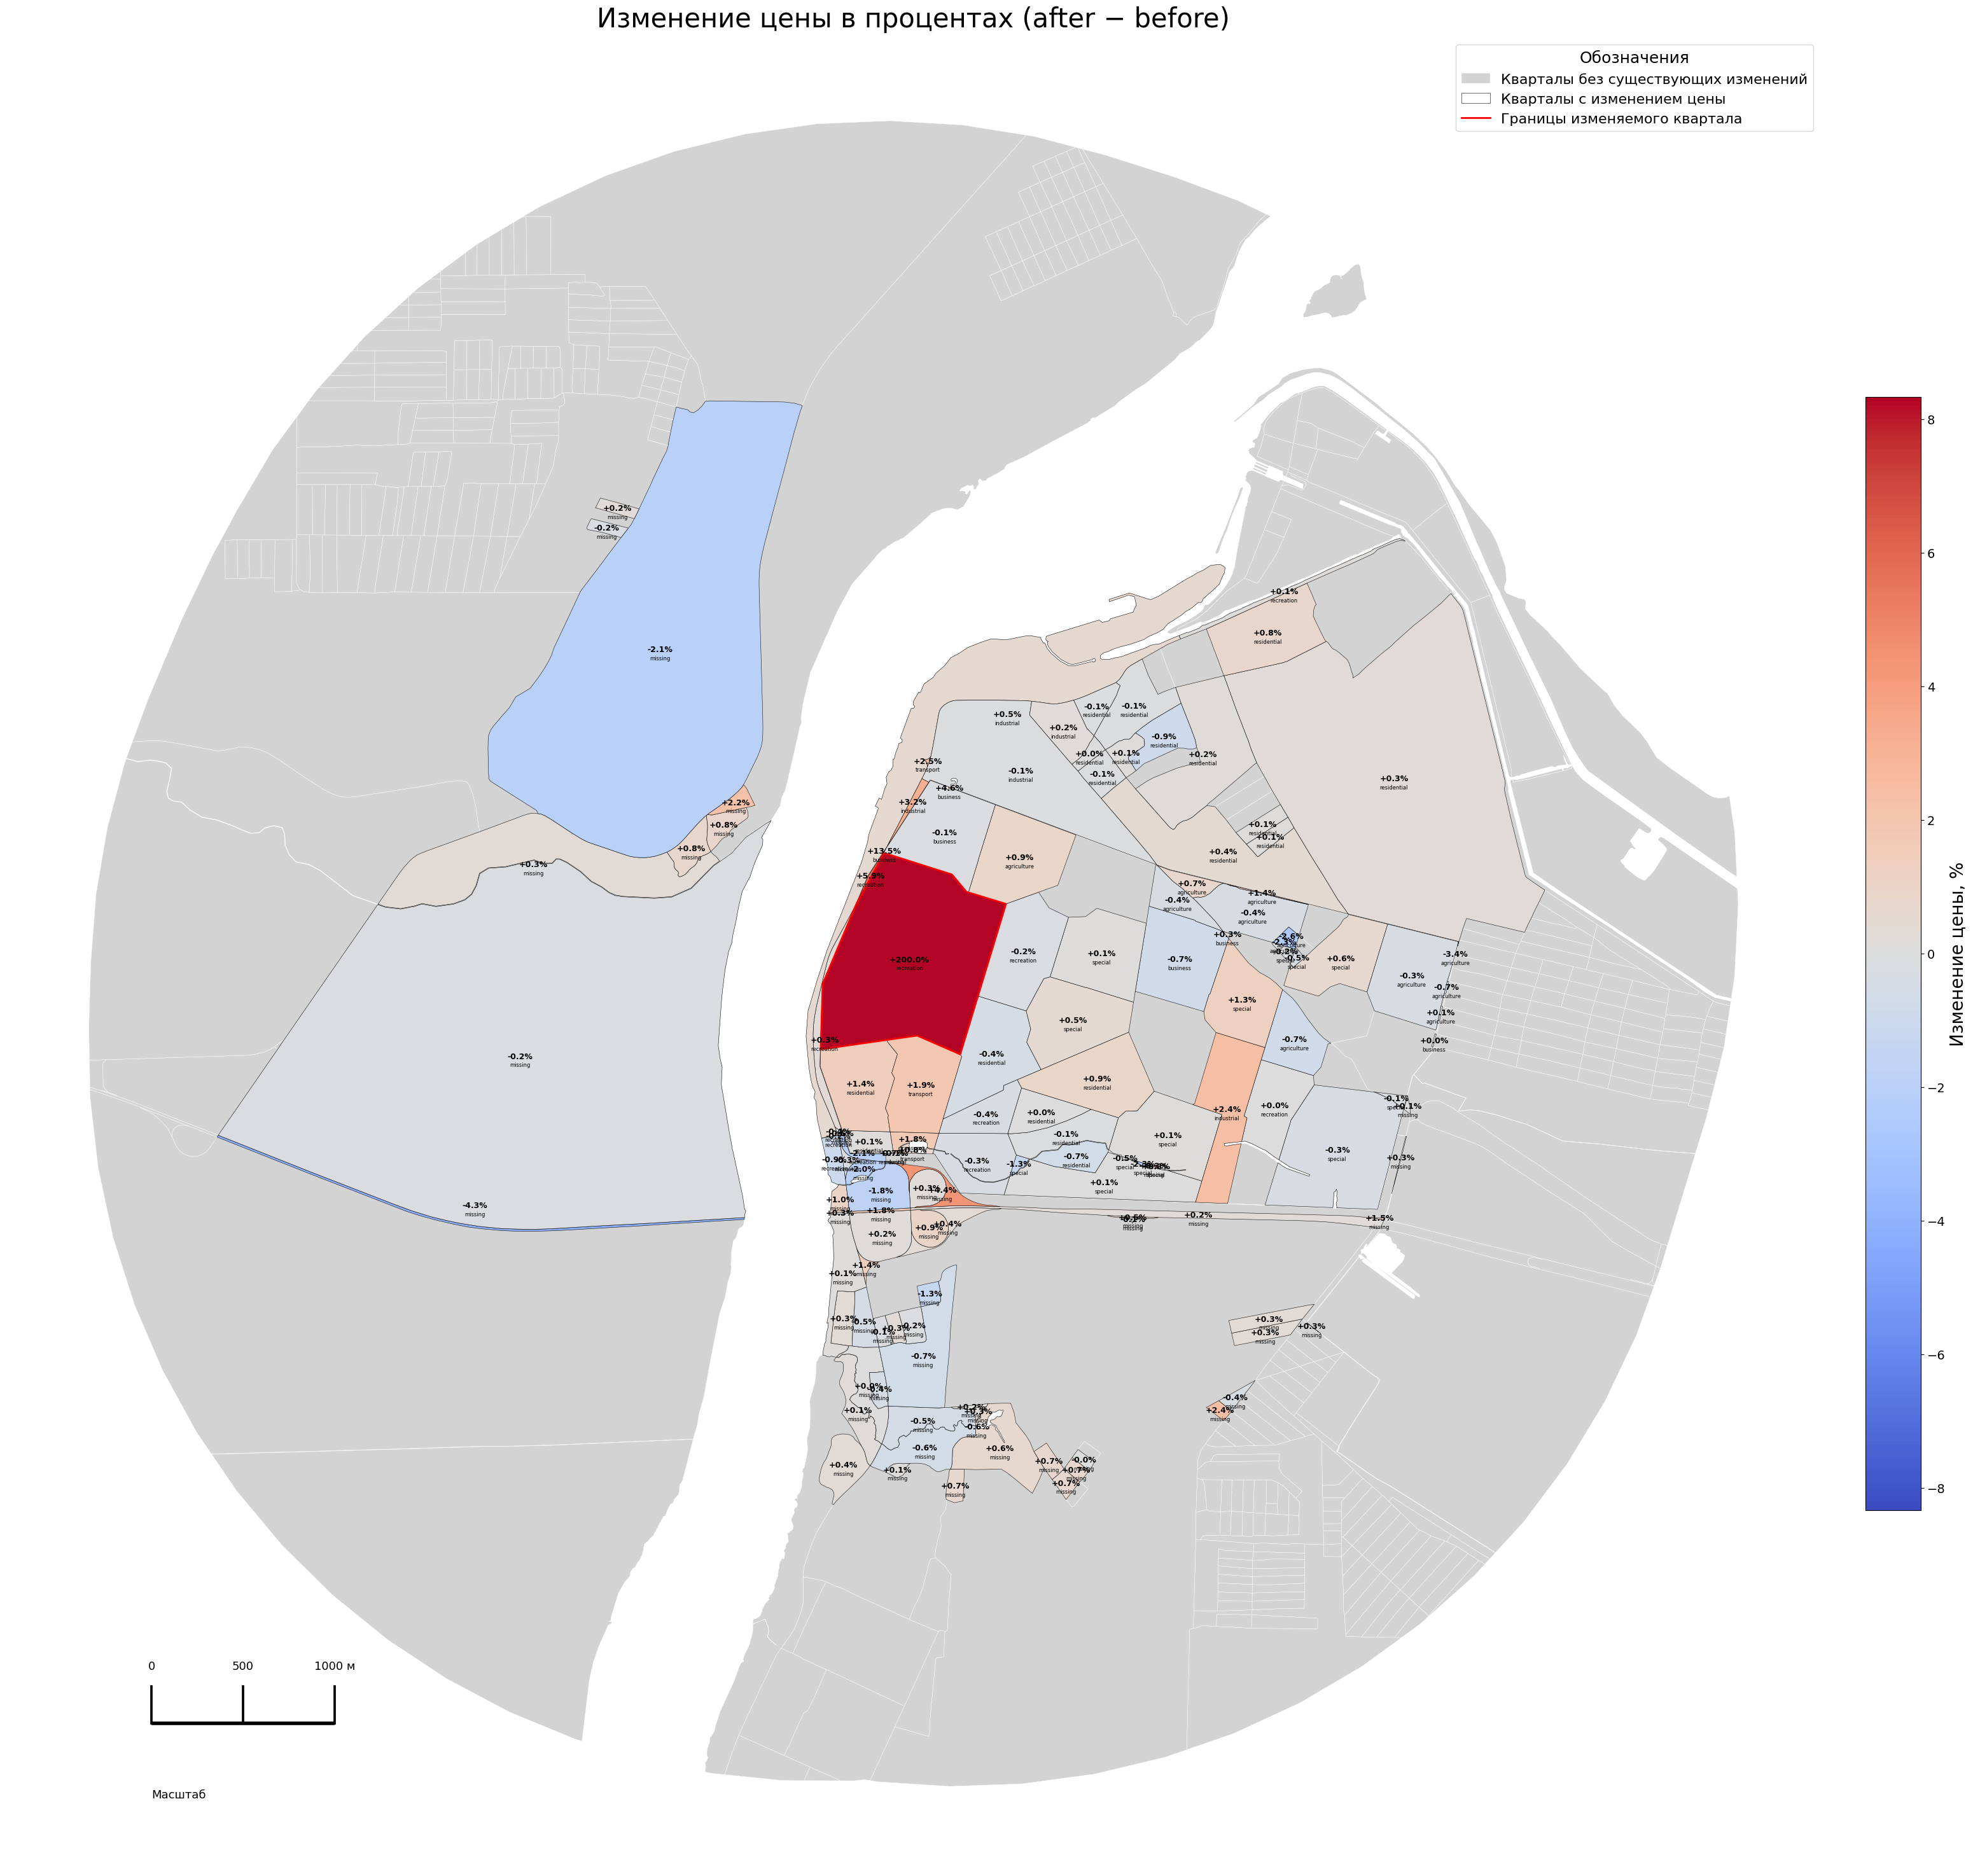


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
62 | recreation | 223 337 143 ₽ → 669 961 892 ₽ | +446 624 749 ₽ | +200.0%

Кварталы в границах проекта:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
12 | special | 162 321 450 ₽ → 162 404 522 ₽ | +83 072 ₽ | +0.1%
49 | special | 57 246 ₽ → 62 015 ₽ | +4 769 ₽ | +8.3%
63 | special | 8 287 150 ₽ → 8 278 747 ₽ | -8 403 ₽ | -0.1%
40 | special | 274 697 126 ₽ → 273 818 254 ₽ | -878 872 ₽ | -0.3%
14 | recreation | 82 367 707 ₽ → 82 399 506 ₽ | +31 800 ₽ | +0.0%
16 | agriculture | 92 336 583 ₽ → 91 666 121 ₽ | -670 462 ₽ | -0.7%
50 | missing | 69 341 ₽ → 75 117 ₽ | +5 777 ₽ | +8.3%
52 | special | 2 869 542 ₽ → 2 803 669 ₽ | -65 873 ₽ | -2.3%
53 | special | 1 446 965 ₽ → 1 439 580 ₽ | -7 385 ₽ | -0.5%
10 | special | 157 405 740 ₽ → 157 569 992 ₽ | +164 252 ₽ | +0.1%
11 | industrial | 161 389 628 ₽ → 165 304 809 ₽ | +3 915 181 ₽ | +2.4%
17 | special | 146 591 000 ₽ → 148

{'map':       residential  business  recreation  industrial  transport  special  \
 388      0.000000  0.000000         0.0    0.000000        0.0      0.0   
 1535     0.000000  0.000000         0.0    0.000000        0.0      0.0   
 1524     0.000000  0.000000         0.0    0.000000        0.0      0.0   
 1536     0.000000  0.000000         0.0    0.000000        0.0      0.0   
 1559     0.000000  0.000000         0.0    0.000000        0.0      0.0   
 ...           ...       ...         ...         ...        ...      ...   
 468      0.422955  0.141693         0.0    0.255331        0.0      0.0   
 469      0.797243  0.000000         0.0    0.044397        0.0      0.0   
 59       0.000000  0.000000         0.0    0.000000        0.0      0.0   
 57       0.000000  0.000000         0.0    0.000000        0.0      0.0   
 37       0.000000  0.000000         0.0    0.000000        0.0      0.0   
 
       agriculture             land_use     share  footprint_area  ...  \
 388 

In [24]:
optimizer.plot_best(genome)